# Project 1: E-Commerce Intelligence - Step 1: Ingestion & Features

This notebook covers the data ingestion, splitting, imputation, feature engineering, and selection pipeline for the relational E-Commerce (Olist) dataset.

## Blueprint Actions Covered
* **Ingestion**: Relational SQLite database ingestion with proper aggregations to prevent row duplication.
* **The Split**: Strict Group-based Train/Validation/Test split (by Customer Unique ID) performed immediately before feature engineering.
* **Feature Engineering**: Parse timestamps, calculate date/time durations, cyclical sin/cos features, and ratio features.
* **Missing Values & Outliers**: Impute values (median/mode), flag missingness, and cap/floor outliers.
* **Encoding & Scaling**: One-Hot encoding inside Scikit-Learn Pipelines with standard scaling.
* **Feature Selection**: Correlation matrix filtering (multicollinearity check) and Variance Thresholding.

In [1]:
import os
import numpy as np
import pandas as pd
import sqlite3
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import VarianceThreshold
from sklearn.base import BaseEstimator, TransformerMixin

# Relational e-commerce datasets directory
DATA_DIR = "../datasets/ecommerce"
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"E-Commerce directory exists: {os.path.exists(DATA_DIR)}")

E-Commerce directory exists: True


## 1. Create SQL Database & Load Datasets

Here we create a local SQLite database and load each of the CSV datasets into it as relational tables.

In [2]:
db_path = os.path.join(DATA_DIR, "ecommerce.db")
print(f"Connecting to SQLite database at: {db_path}")
conn = sqlite3.connect(db_path)

# Find all CSV files in the ecommerce directory and load them as tables
csv_files = glob.glob(os.path.join(DATA_DIR, "*.csv"))
for file_path in csv_files:
    filename = os.path.basename(file_path)
    # Standardize table name: e.g. olist_customers_dataset.csv -> olist_customers
    table_name = filename.replace(".csv", "").replace("_dataset", "")
    print(f"Loading table '{table_name}' from {filename}...")
    df_temp = pd.read_csv(file_path)
    df_temp.to_sql(table_name, conn, if_exists="replace", index=False)

print("All datasets loaded successfully into SQLite!")

Connecting to SQLite database at: ../datasets/ecommerce/ecommerce.db
Loading table 'olist_orders' from olist_orders_dataset.csv...
Loading table 'olist_order_items' from olist_order_items_dataset.csv...
Loading table 'olist_order_reviews' from olist_order_reviews_dataset.csv...
Loading table 'olist_customers' from olist_customers_dataset.csv...
Loading table 'olist_geolocation' from olist_geolocation_dataset.csv...
Loading table 'olist_order_payments' from olist_order_payments_dataset.csv...
Loading table 'product_category_name_translation' from product_category_name_translation.csv...
Loading table 'olist_sellers' from olist_sellers_dataset.csv...
Loading table 'olist_products' from olist_products_dataset.csv...
All datasets loaded successfully into SQLite!


## 2. Load Unified E-Commerce Data as a Single DataFrame

We write a SQL query to join the relevant relational tables. To prevent row duplication (and subsequent data leakage during split), we aggregate payments, reviews, and geolocations before joining.

In [3]:
# SQL query to join all relevant tables with proper aggregations
query = """
WITH aggregated_payments AS (
    SELECT 
        order_id,
        SUM(payment_value) AS total_payment_value,
        MAX(payment_installments) AS max_payment_installments,
        COUNT(DISTINCT payment_type) AS unique_payment_types,
        MAX(payment_type) AS primary_payment_type
    FROM olist_order_payments
    GROUP BY order_id
),
aggregated_reviews AS (
    SELECT 
        order_id,
        AVG(review_score) AS avg_review_score,
        COUNT(review_id) AS review_count
    FROM olist_order_reviews
    GROUP BY order_id
),
aggregated_geolocation AS (
    SELECT 
        geolocation_zip_code_prefix,
        AVG(geolocation_lat) AS geo_lat,
        AVG(geolocation_lng) AS geo_lng
    FROM olist_geolocation
    GROUP BY geolocation_zip_code_prefix
)
SELECT 
    o.order_id,
    o.customer_id,
    o.order_status,
    o.order_purchase_timestamp,
    o.order_approved_at,
    o.order_delivered_carrier_date,
    o.order_delivered_customer_date,
    o.order_estimated_delivery_date,
    
    oi.order_item_id,
    oi.product_id,
    oi.seller_id,
    oi.shipping_limit_date,
    oi.price,
    oi.freight_value,
    
    c.customer_unique_id,
    c.customer_zip_code_prefix,
    c.customer_city,
    c.customer_state,
    cg.geo_lat AS customer_lat,
    cg.geo_lng AS customer_lng,
    
    p.product_category_name,
    t.product_category_name_english,
    p.product_name_lenght,
    p.product_description_lenght,
    p.product_photos_qty,
    p.product_weight_g,
    p.product_length_cm,
    p.product_height_cm,
    p.product_width_cm,
    
    s.seller_zip_code_prefix,
    s.seller_city,
    s.seller_state,
    sg.geo_lat AS seller_lat,
    sg.geo_lng AS seller_lng,
    
    pay.total_payment_value,
    pay.max_payment_installments,
    pay.unique_payment_types,
    pay.primary_payment_type,
    
    r.avg_review_score,
    r.review_count

FROM olist_orders o
LEFT JOIN olist_order_items oi ON o.order_id = oi.order_id
LEFT JOIN olist_customers c ON o.customer_id = c.customer_id
LEFT JOIN olist_products p ON oi.product_id = p.product_id
LEFT JOIN product_category_name_translation t ON p.product_category_name = t.product_category_name
LEFT JOIN olist_sellers s ON oi.seller_id = s.seller_id
LEFT JOIN aggregated_payments pay ON o.order_id = pay.order_id
LEFT JOIN aggregated_reviews r ON o.order_id = r.order_id
LEFT JOIN aggregated_geolocation cg ON c.customer_zip_code_prefix = cg.geolocation_zip_code_prefix
LEFT JOIN aggregated_geolocation sg ON s.seller_zip_code_prefix = sg.geolocation_zip_code_prefix
"""

df_master = pd.read_sql_query(query, conn)
conn.close()

print(f"Master DataFrame successfully loaded! Shape: {df_master.shape}")
df_master.head()

Master DataFrame successfully loaded! Shape: (113425, 40)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,seller_city,seller_state,seller_lat,seller_lng,total_payment_value,max_payment_installments,unique_payment_types,primary_payment_type,avg_review_score,review_count
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,maua,SP,-23.680729,-46.444238,38.71,1.0,2.0,voucher,4.0,1.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,595fac2a385ac33a80bd5114aec74eb8,...,belo horizonte,SP,-19.807681,-43.980427,141.46,1.0,1.0,boleto,4.0,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,aa4383b373c6aca5d8797843e5594415,...,guariba,SP,-21.363502,-48.229601,179.12,3.0,1.0,credit_card,5.0,1.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,...,belo horizonte,MG,-19.837682,-43.924053,72.20,1.0,1.0,credit_card,5.0,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1.0,65266b2da20d04dbe00c5c2d3bb7859e,...,mogi das cruzes,SP,-23.543395,-46.262086,28.62,1.0,1.0,credit_card,5.0,1.0


In [4]:
df_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       113425 non-null  str    
 1   customer_id                    113425 non-null  str    
 2   order_status                   113425 non-null  str    
 3   order_purchase_timestamp       113425 non-null  str    
 4   order_approved_at              113264 non-null  str    
 5   order_delivered_carrier_date   111457 non-null  str    
 6   order_delivered_customer_date  110196 non-null  str    
 7   order_estimated_delivery_date  113425 non-null  str    
 8   order_item_id                  112650 non-null  float64
 9   product_id                     112650 non-null  str    
 10  seller_id                      112650 non-null  str    
 11  shipping_limit_date            112650 non-null  str    
 12  price                          112650 non

## 3. The Split (Preventing Data Leakage)

To guarantee there is no data leakage across the train/validation/test sets, we split unique customer IDs (`customer_unique_id`) rather than split transaction rows randomly. This ensures that any customer's historical orders belong exclusively to one split.

In [5]:
# Drop rows where customer_unique_id is null
df_master = df_master.dropna(subset=['customer_unique_id'])

# Get unique customer IDs
unique_customers = df_master['customer_unique_id'].unique()

# Split: 80% Train, 20% Temp
train_cust, temp_cust = train_test_split(unique_customers, test_size=0.2, random_state=42)
# Split Temp into 50% Val, 50% Test (10% and 10% of total)
val_cust, test_cust = train_test_split(temp_cust, test_size=0.5, random_state=42)

print(f"Train customer count: {len(train_cust)}")
print(f"Validation customer count: {len(val_cust)}")
print(f"Test customer count: {len(test_cust)}")

# Filter the master dataframe
train_raw = df_master[df_master['customer_unique_id'].isin(train_cust)].copy()
val_raw = df_master[df_master['customer_unique_id'].isin(val_cust)].copy()
test_raw = df_master[df_master['customer_unique_id'].isin(test_cust)].copy()

print(f"Train Raw Shape: {train_raw.shape}")
print(f"Validation Raw Shape: {val_raw.shape}")
print(f"Test Raw Shape: {test_raw.shape}")

# Verify zero customer ID overlap
overlap_train_val = set(train_raw['customer_unique_id']).intersection(set(val_raw['customer_unique_id']))
overlap_train_test = set(train_raw['customer_unique_id']).intersection(set(test_raw['customer_unique_id']))
overlap_val_test = set(val_raw['customer_unique_id']).intersection(set(test_raw['customer_unique_id']))
print(f"Overlap Train/Val: {len(overlap_train_val)}")
print(f"Overlap Train/Test: {len(overlap_train_test)}")
print(f"Overlap Val/Test: {len(overlap_val_test)}")

Train customer count: 76876
Validation customer count: 9610
Test customer count: 9610
Train Raw Shape: (90817, 40)
Validation Raw Shape: (11331, 40)
Test Raw Shape: (11277, 40)
Overlap Train/Val: 0
Overlap Train/Test: 0
Overlap Val/Test: 0


## 4. Feature Engineering & Transformations

We construct transactional and customer-level features row-by-row:
* **Temporal Features**: Parsing raw timestamps to extract year, month, day, day of week, hour. Cyclical month/dayofweek/hour attributes are generated using sine and cosine transformations to capture periodic seasonality.
* **Delivery Durations**: Delays in delivery, actual delivery speed, and courier shipping times.
* **Financial & Product Features**: Volumetric volume of product, freight cost relative to item cost ratio.

In [6]:
def engineer_features(df):
    df_out = df.copy()
    
    # Parse date columns
    date_cols = [
        'order_purchase_timestamp', 'order_approved_at', 
        'order_delivered_carrier_date', 'order_delivered_customer_date', 
        'order_estimated_delivery_date', 'shipping_limit_date'
    ]
    for col in date_cols:
        df_out[col] = pd.to_datetime(df_out[col])
        
    # Temporal features (Month, Hour, DayOfWeek)
    df_out['purchase_year'] = df_out['order_purchase_timestamp'].dt.year
    df_out['purchase_month'] = df_out['order_purchase_timestamp'].dt.month
    df_out['purchase_day'] = df_out['order_purchase_timestamp'].dt.day
    df_out['purchase_dayofweek'] = df_out['order_purchase_timestamp'].dt.dayofweek
    df_out['purchase_hour'] = df_out['order_purchase_timestamp'].dt.hour
    
    # Cyclical representations
    df_out['purchase_month_sin'] = np.sin(2 * np.pi * df_out['purchase_month'] / 12.0)
    df_out['purchase_month_cos'] = np.cos(2 * np.pi * df_out['purchase_month'] / 12.0)
    df_out['purchase_dayofweek_sin'] = np.sin(2 * np.pi * df_out['purchase_dayofweek'] / 7.0)
    df_out['purchase_dayofweek_cos'] = np.cos(2 * np.pi * df_out['purchase_dayofweek'] / 7.0)
    df_out['purchase_hour_sin'] = np.sin(2 * np.pi * df_out['purchase_hour'] / 24.0)
    df_out['purchase_hour_cos'] = np.cos(2 * np.pi * df_out['purchase_hour'] / 24.0)
    
    # Delivery Duration Features (measured in days or hours)
    df_out['estimated_delivery_duration_days'] = (df_out['order_estimated_delivery_date'] - df_out['order_purchase_timestamp']).dt.total_seconds() / (24 * 3600)
    df_out['actual_delivery_duration_days'] = (df_out['order_delivered_customer_date'] - df_out['order_purchase_timestamp']).dt.total_seconds() / (24 * 3600)
    df_out['delivery_delay_days'] = (df_out['order_delivered_customer_date'] - df_out['order_estimated_delivery_date']).dt.total_seconds() / (24 * 3600)
    df_out['approval_delay_hours'] = (df_out['order_approved_at'] - df_out['order_purchase_timestamp']).dt.total_seconds() / 3600.0
    df_out['carrier_delay_days'] = (df_out['order_delivered_carrier_date'] - df_out['order_approved_at']).dt.total_seconds() / (24 * 3600)
    
    # Product and Order Features
    df_out['product_volume_cm3'] = df_out['product_length_cm'] * df_out['product_height_cm'] * df_out['product_width_cm']
    df_out['freight_ratio'] = df_out['freight_value'] / (df_out['price'] + 1e-5)
    
    return df_out

print("Engineering features on Train, Validation, and Test sets...")
train_eng = engineer_features(train_raw)
val_eng = engineer_features(val_raw)
test_eng = engineer_features(test_raw)

print("Feature engineering complete!")

Engineering features on Train, Validation, and Test sets...
Feature engineering complete!


## 5. Exploratory Data Analysis (EDA)

To understand our data distributions, identify outliers, and check temporal trends, we perform Exploratory Data Analysis (EDA) exclusively on the training split (`train_eng`) to prevent any data leakage. All generated plots are saved to the `plots/` directory.

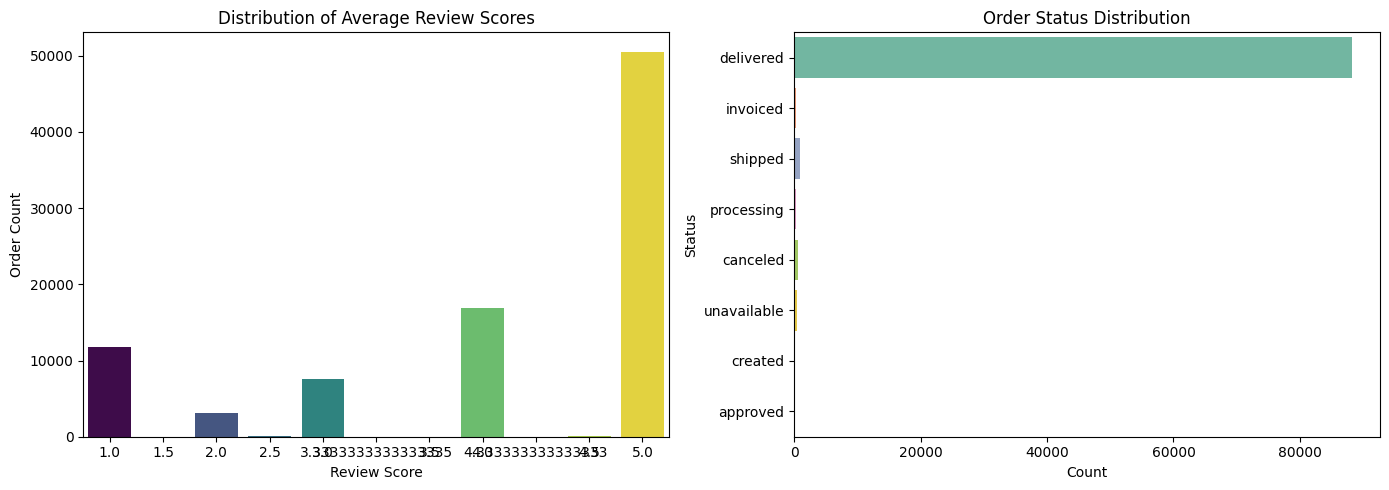

In [7]:
# Create plots directory if not exists
os.makedirs("plots", exist_ok=True)

# 1. Target and Churn/Order Status Distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average Review Score distribution
sns.countplot(data=train_eng, x='avg_review_score', ax=axes[0], hue='avg_review_score', palette='viridis', legend=False)
axes[0].set_title('Distribution of Average Review Scores')
axes[0].set_xlabel('Review Score')
axes[0].set_ylabel('Order Count')

# Order status distribution
sns.countplot(data=train_eng, y='order_status', ax=axes[1], hue='order_status', palette='Set2', legend=False)
axes[1].set_title('Order Status Distribution')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Status')

plt.tight_layout()
plt.savefig('plots/review_score_distribution.png', dpi=300)
plt.show()

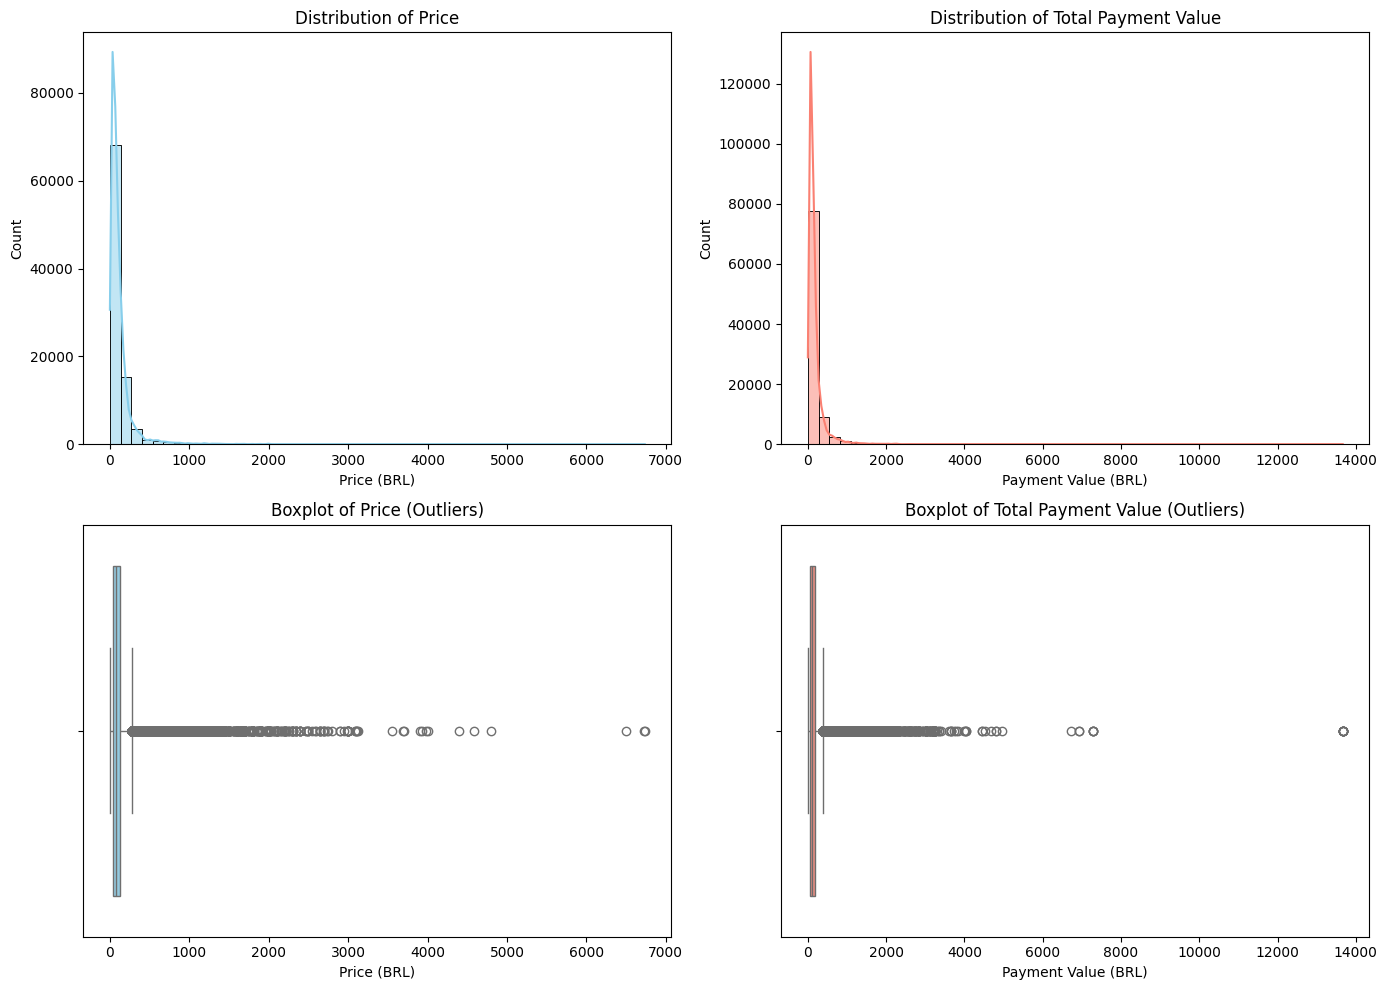

In [8]:
# 2. Key numerical distributions and potential outliers
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Price distribution
sns.histplot(data=train_eng, x='price', bins=50, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribution of Price')
axes[0, 0].set_xlabel('Price (BRL)')

# Total payment value distribution
sns.histplot(data=train_eng, x='total_payment_value', bins=50, kde=True, ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('Distribution of Total Payment Value')
axes[0, 1].set_xlabel('Payment Value (BRL)')

# Boxplot for Price to see outliers
sns.boxplot(data=train_eng, x='price', ax=axes[1, 0], color='skyblue')
axes[1, 0].set_title('Boxplot of Price (Outliers)')
axes[1, 0].set_xlabel('Price (BRL)')

# Boxplot for Total Payment Value to see outliers
sns.boxplot(data=train_eng, x='total_payment_value', ax=axes[1, 1], color='salmon')
axes[1, 1].set_title('Boxplot of Total Payment Value (Outliers)')
axes[1, 1].set_xlabel('Payment Value (BRL)')

plt.tight_layout()
plt.savefig('plots/price_payment_distributions.png', dpi=300)
plt.show()

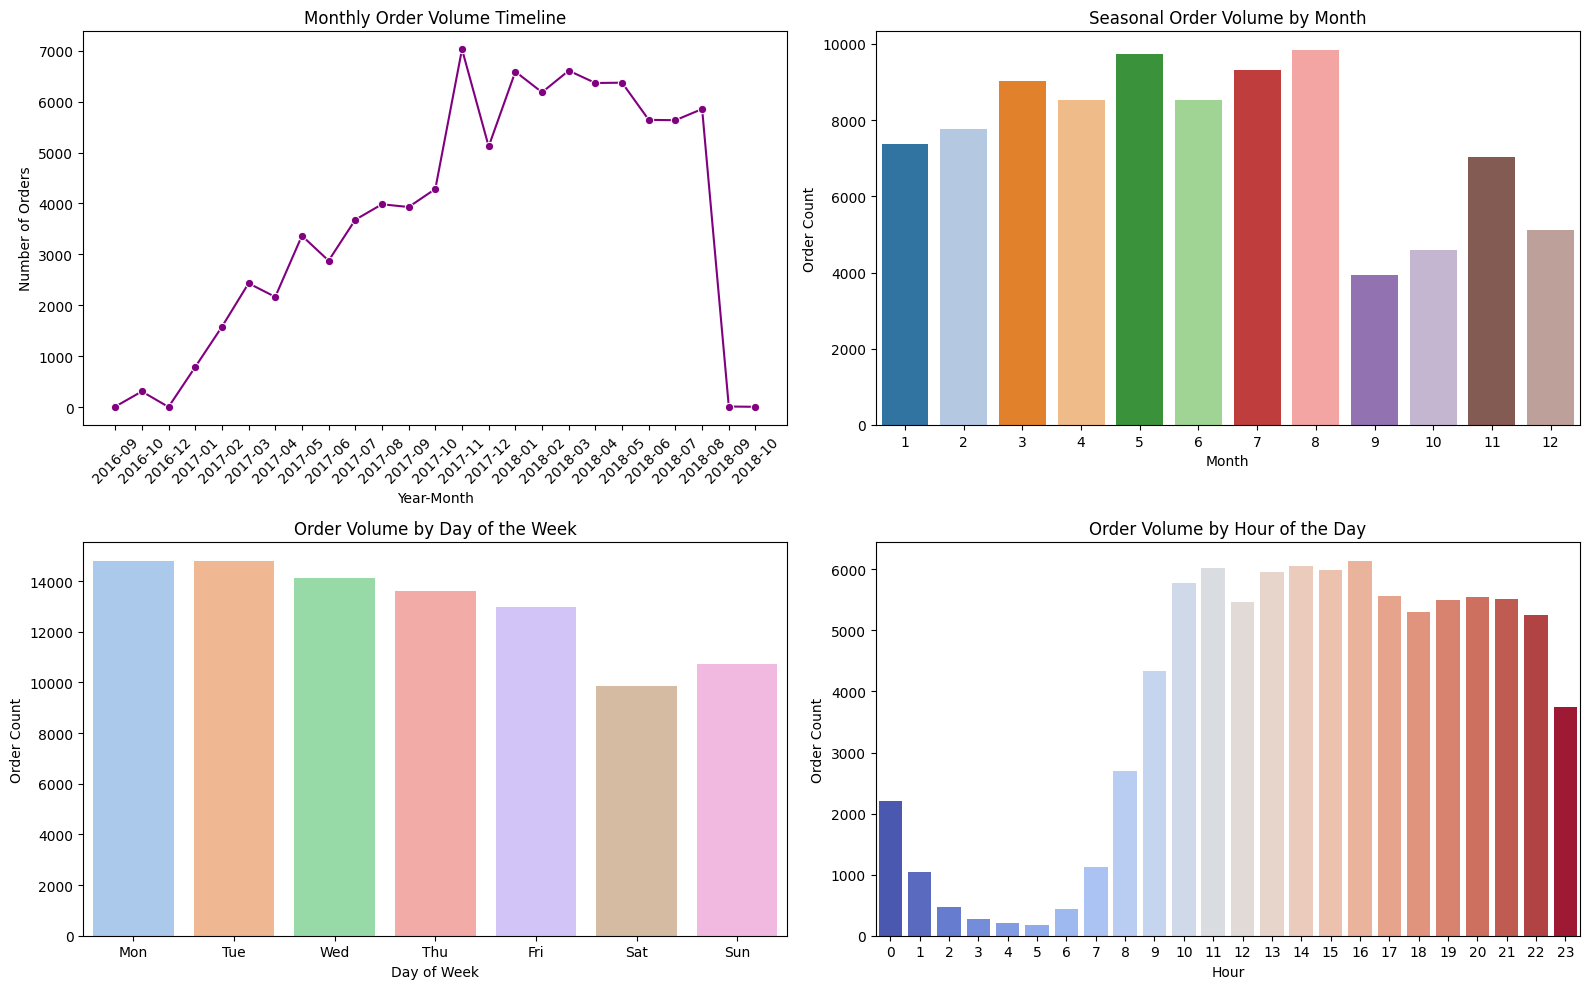

In [9]:
# 3. Temporal trends and periodicity
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Monthly order trends (Timeline)
train_eng['purchase_year_month'] = train_eng['order_purchase_timestamp'].dt.to_period('M')
monthly_orders = train_eng.groupby('purchase_year_month').size()
monthly_orders.index = monthly_orders.index.astype(str)
sns.lineplot(x=monthly_orders.index, y=monthly_orders.values, ax=axes[0, 0], marker='o', color='purple')
axes[0, 0].set_title('Monthly Order Volume Timeline')
axes[0, 0].set_xlabel('Year-Month')
axes[0, 0].set_ylabel('Number of Orders')
axes[0, 0].tick_params(axis='x', rotation=45)

# Seasonality by Month
sns.countplot(data=train_eng, x='purchase_month', ax=axes[0, 1], hue='purchase_month', palette='tab20', legend=False)
axes[0, 1].set_title('Seasonal Order Volume by Month')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Order Count')

# Weekly Seasonality (Day of Week)
days_map = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
sns.countplot(data=train_eng, x='purchase_dayofweek', ax=axes[1, 0], hue='purchase_dayofweek', palette='pastel', legend=False)
axes[1, 0].set_title('Order Volume by Day of the Week')
axes[1, 0].set_xlabel('Day of Week')
axes[1, 0].set_xticks(range(7))
axes[1, 0].set_xticklabels([days_map[i] for i in range(7)])
axes[1, 0].set_ylabel('Order Count')

# Hourly Seasonality
sns.countplot(data=train_eng, x='purchase_hour', ax=axes[1, 1], hue='purchase_hour', palette='coolwarm', legend=False)
axes[1, 1].set_title('Order Volume by Hour of the Day')
axes[1, 1].set_xlabel('Hour')
axes[1, 1].set_ylabel('Order Count')

# Clean up temporary column
train_eng.drop(columns=['purchase_year_month'], inplace=True, errors='ignore')

plt.tight_layout()
plt.savefig('plots/temporal_seasonality_trends.png', dpi=300)
plt.show()

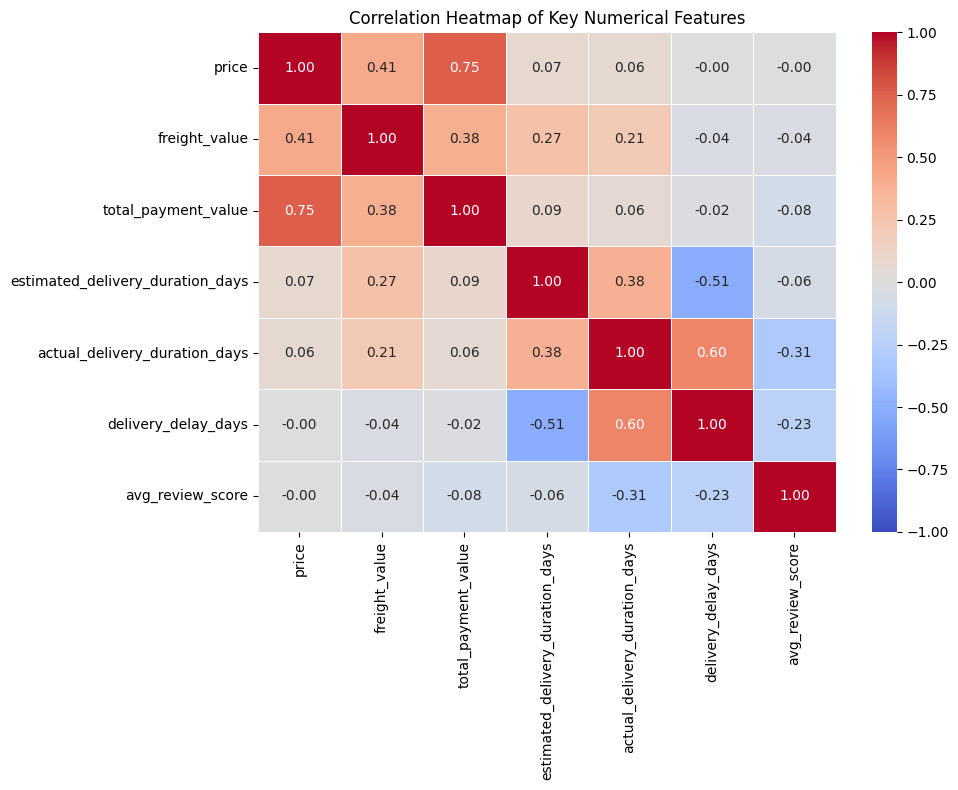

In [10]:
# 4. Correlation Heatmap of key numerical features
key_num_cols = [
    'price', 'freight_value', 'total_payment_value', 
    'estimated_delivery_duration_days', 'actual_delivery_duration_days', 
    'delivery_delay_days', 'avg_review_score'
]
corr_sub = train_eng[key_num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_sub, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Key Numerical Features')
plt.tight_layout()
plt.savefig('plots/correlation_heatmap.png', dpi=300)
plt.show()

## 6. Preprocessing Pipelines (Imputation, Capping & Scaling)

In [11]:
# Custom Outlier Capper Transformer
class OutlierCapper(BaseEstimator, TransformerMixin):
    def __init__(self, lower_quantile=0.01, upper_quantile=0.99):
        self.lower_quantile = lower_quantile
        self.upper_quantile = upper_quantile
        self.lower_bounds_ = {}
        self.upper_bounds_ = {}

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        for col in X_df.columns:
            if pd.api.types.is_numeric_dtype(X_df[col]):
                self.lower_bounds_[col] = X_df[col].quantile(self.lower_quantile)
                self.upper_bounds_[col] = X_df[col].quantile(self.upper_quantile)
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X).copy()
        for col in X_df.columns:
            if col in self.lower_bounds_:
                X_df[col] = X_df[col].clip(lower=self.lower_bounds_[col], upper=self.upper_bounds_[col])
        return X_df.values if isinstance(X, np.ndarray) else X_df

# Define feature columns
num_features = [
    'price', 'freight_value', 'product_name_lenght', 'product_description_lenght', 
    'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 
    'product_width_cm', 'customer_lat', 'customer_lng', 'seller_lat', 'seller_lng',
    'total_payment_value', 'max_payment_installments', 'unique_payment_types', 
    'avg_review_score', 'review_count', 'purchase_year', 'purchase_month', 'purchase_day',
    'purchase_dayofweek', 'purchase_hour', 'purchase_month_sin', 'purchase_month_cos', 
    'purchase_dayofweek_sin', 'purchase_dayofweek_cos', 'purchase_hour_sin', 'purchase_hour_cos',
    'estimated_delivery_duration_days', 'actual_delivery_duration_days', 'delivery_delay_days', 
    'approval_delay_hours', 'carrier_delay_days', 'product_volume_cm3', 'freight_ratio'
]

cat_features = [
    'order_status', 'primary_payment_type', 'customer_state', 'seller_state', 
    'product_category_name_english'
]

# Pipelines
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
    ('capper', OutlierCapper(lower_quantile=0.01, upper_quantile=0.99)),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features)
    ],
    remainder='drop'
)

# Apply preprocessing
print("Fitting pipeline on training data and transforming all splits...")
X_train_proc = preprocessor.fit_transform(train_eng)
X_val_proc = preprocessor.transform(val_eng)
X_test_proc = preprocessor.transform(test_eng)

# Get output feature names
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['encoder']
cat_columns_transformed = cat_encoder.get_feature_names_out(cat_features).tolist()

# Recover imputed numerical feature names (including indicators)
num_imputer = preprocessor.named_transformers_['num'].named_steps['imputer']
indicator_cols = []
if num_imputer.add_indicator:
    # Get missing indicator columns
    indicator_cols = [f"missing_{num_features[idx]}" for idx in num_imputer.indicator_.features_]

feature_names = num_features + indicator_cols + cat_columns_transformed

# Convert to dataframes
X_train_df = pd.DataFrame(X_train_proc, columns=feature_names, index=train_eng.index)
X_val_df = pd.DataFrame(X_val_proc, columns=feature_names, index=val_eng.index)
X_test_df = pd.DataFrame(X_test_proc, columns=feature_names, index=test_eng.index)

print(f"Train Preprocessed Shape: {X_train_df.shape}")
print(f"Validation Preprocessed Shape: {X_val_df.shape}")
print(f"Test Preprocessed Shape: {X_test_df.shape}")

Fitting pipeline on training data and transforming all splits...
Train Preprocessed Shape: (90817, 197)
Validation Preprocessed Shape: (11331, 197)
Test Preprocessed Shape: (11277, 197)


## 7. Feature Selection

In [12]:
# Drop highly collinear features
corr_matrix = X_train_df[num_features].corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
# print('upper tri',upper_tri)
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.95)]
# print('to_drop',to_drop)
print(f"Collinear features to drop (corr > 0.95): {to_drop}")

# Drop collinear columns
X_train_sel1 = X_train_df.drop(columns=to_drop)
X_val_sel1 = X_val_df.drop(columns=to_drop)
X_test_sel1 = X_test_df.drop(columns=to_drop)

# Apply Variance Thresholding to drop low variance columns
selector = VarianceThreshold(threshold=0.01)
selector.fit(X_train_sel1)

selected_cols = X_train_sel1.columns[selector.get_support()]
print(f"Features kept after Variance Thresholding: {len(selected_cols)} / {X_train_sel1.shape[1]}")

X_train_final = X_train_sel1[selected_cols]
X_val_final = X_val_sel1[selected_cols]
X_test_final = X_test_sel1[selected_cols]

print(f"Final Train Shape: {X_train_final.shape}")
print(f"Final Validation Shape: {X_val_final.shape}")
print(f"Final Test Shape: {X_test_final.shape}")

Collinear features to drop (corr > 0.95): []
Features kept after Variance Thresholding: 85 / 197
Final Train Shape: (90817, 85)
Final Validation Shape: (11331, 85)
Final Test Shape: (11277, 85)


## 8. Save Cleaned Splits & Features

In [13]:
# Save final preprocessed features to compressed CSVs
X_train_final.to_csv(os.path.join(OUTPUT_DIR, "X_train_processed.csv.gz"), index=True, compression='gzip')
X_val_final.to_csv(os.path.join(OUTPUT_DIR, "X_val_processed.csv.gz"), index=True, compression='gzip')
X_test_final.to_csv(os.path.join(OUTPUT_DIR, "X_test_processed.csv.gz"), index=True, compression='gzip')

# Save raw splits (metadata, timestamps, target labels like review scores)
train_eng.to_csv(os.path.join(OUTPUT_DIR, "train_raw_engineered.csv.gz"), index=True, compression='gzip')
val_eng.to_csv(os.path.join(OUTPUT_DIR, "val_raw_engineered.csv.gz"), index=True, compression='gzip')
test_eng.to_csv(os.path.join(OUTPUT_DIR, "test_raw_engineered.csv.gz"), index=True, compression='gzip')

print("All outputs successfully saved to outputs/ directory!")

All outputs successfully saved to outputs/ directory!


,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_lat,...,product_category_name_english_housewares,product_category_name_english_missing,product_category_name_english_office_furniture,product_category_name_english_perfumery,product_category_name_english_pet_shop,product_category_name_english_sports_leisure,product_category_name_english_stationery,product_category_name_english_telephony,product_category_name_english_toys,product_category_name_english_watches_gifts
41,-0.574000,-0.534075,-0.497907,-0.932104,-0.712106,-0.390315,0.630558,-0.983267,0.645959,-0.429643,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
57,-0.562914,-0.607625,-0.803620,0.012355,-0.712106,-0.316276,-0.636773,1.477884,-0.255816,-0.322016,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
88,-0.425517,-0.295427,0.215423,0.344577,-0.102177,-0.479162,-0.763506,-0.427524,-0.255816,1.031545,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
89,-0.425517,-0.295427,0.215423,0.344577,-0.102177,-0.479162,-0.763506,-0.427524,-0.255816,1.031545,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
102,2.071939,-0.369760,-0.701716,-0.737517,-0.712106,-0.356849,0.123625,-0.030564,-0.616526,0.010810,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113362,0.150307,-0.776635,0.724945,-0.248676,-0.102177,-0.390315,-0.383307,-0.189348,-0.436171,-0.439022,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
113395,1.784433,-0.117029,0.419232,0.512270,-0.712106,0.231616,-0.129841,0.525180,0.014717,-0.417958,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
113396,1.784433,-0.117029,0.419232,0.512270,-0.712106,0.231616,-0.129841,0.525180,0.014717,-0.417958,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
113406,1.369804,-0.020787,0.623041,-0.267660,-0.712106,-0.034926,0.313725,1.080924,0.195072,-0.096479,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
